# Predictive Churn Analysis

### *load dataset*

In [10]:
import pandas as pd

df = pd.read_csv("customer_churn_sample.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

Dataset loaded successfully!
Shape: (15, 11)
Missing Values:
CustomerID          0
Gender              0
Age                 0
TenureMonths        0
SubscriptionType    0
MonthlyCharges      0
TotalCharges        0
ContractType        0
SupportTickets      0
PaymentMethod       0
Churn               0
dtype: int64

Duplicate Rows: 0

Churn Distribution:
Churn
No     8
Yes    7
Name: count, dtype: int64


In [11]:
# Convert target variable to 0 and 1
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Features
X = df.drop(columns=["CustomerID", "Churn"])

# Target
y = df["Churn"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.value_counts())

Features:
['Gender', 'Age', 'TenureMonths', 'SubscriptionType', 'MonthlyCharges', 'TotalCharges', 'ContractType', 'SupportTickets', 'PaymentMethod']

Target:
Churn
0    8
1    7
Name: count, dtype: int64


### *numerical and categorical features*

In [21]:
numeric_features = [
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "TotalCharges",
    "SupportTickets"
]

categorical_features = [
    "Gender",
    "SubscriptionType",
    "ContractType",
    "PaymentMethod"
]

### *80/20 train-test split*

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 12
Testing samples: 3

Training target distribution:
Churn
0    6
1    6
Name: count, dtype: int64

Testing target distribution:
Churn
0    2
1    1
Name: count, dtype: int64


### *One-Hot Encoding + MinMax Scaling*

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            MinMaxScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

## *Logistic Regression*

In [23]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

#Train model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

y_pred = model.predict(X_test)

y_probability = model.predict_proba(X_test)[:, 1]

print("Predicted Classes:")
print(y_pred)

print("\nChurn Probabilities:")
print(y_probability)



Logistic Regression model trained successfully!
Predicted Classes:
[0 1 0]

Churn Probabilities:
[0.10074724 0.78934946 0.34032821]


### *Precision, Recall and F1-score*

In [24]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))




print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Classification Report:

              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00         2
       Churn       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### *ROC-AUC*

In [25]:
roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 1.0


### *Confusion Matrix*

Confusion Matrix:
[[2 0]
 [0 1]]


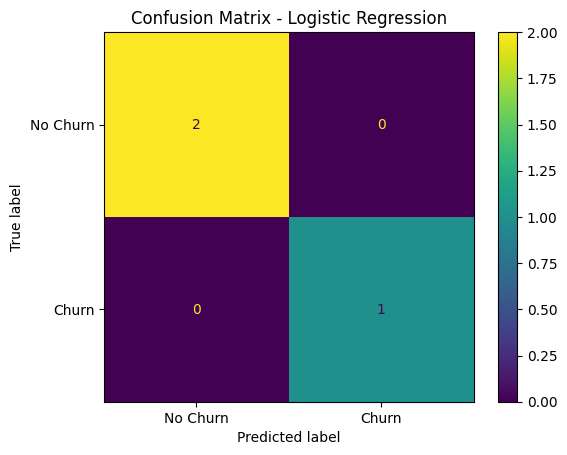

In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### *ROC Curve*

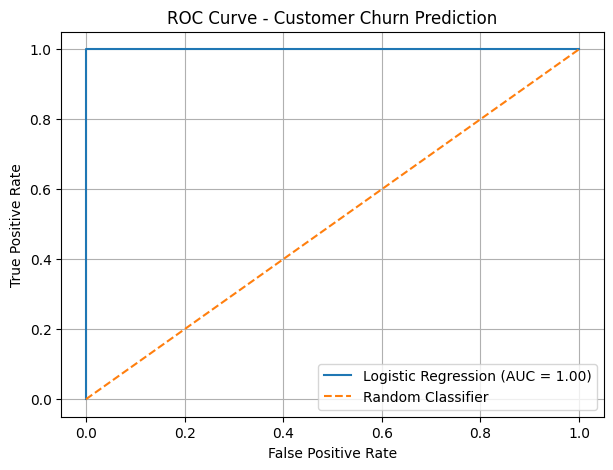

In [16]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid()
plt.show()

### *Customer churn risk scores*

In [17]:
# Predict churn probability for ALL customers
all_X = df.drop(columns=["CustomerID", "Churn"])

all_probabilities = model.predict_proba(all_X)[:, 1]

all_predictions = model.predict(all_X)

risk_df = pd.DataFrame({
    "CustomerID": df["CustomerID"],
    "ActualChurn": df["Churn"],
    "PredictedChurn": all_predictions,
    "ChurnProbability": all_probabilities
})

# Convert probability to percentage
risk_df["ChurnProbability"] = (
    risk_df["ChurnProbability"] * 100
).round(2)

# Create risk categories
def risk_category(probability):
    if probability >= 70:
        return "High Risk"
    elif probability >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

risk_df["RiskCategory"] = risk_df["ChurnProbability"].apply(
    risk_category
)

risk_df

,CustomerID,ActualChurn,PredictedChurn,ChurnProbability,RiskCategory
0,CUST-1001,1,1,68.70,Medium Risk
1,CUST-1002,0,0,24.90,Low Risk
2,CUST-1003,1,1,81.06,High Risk
3,CUST-1004,0,0,10.92,Low Risk
4,CUST-1005,1,1,79.33,High Risk
5,CUST-1006,0,0,40.91,Medium Risk
6,CUST-1007,1,1,80.76,High Risk
7,CUST-1008,0,0,10.07,Low Risk
8,CUST-1009,0,0,33.24,Low Risk
9,CUST-1010,1,1,76.19,High Risk


### *Sort customers by risk*

In [18]:
risk_df_sorted = risk_df.sort_values(
    by="ChurnProbability",
    ascending=False
)

risk_df_sorted

,CustomerID,ActualChurn,PredictedChurn,ChurnProbability,RiskCategory
2,CUST-1003,1,1,81.06,High Risk
6,CUST-1007,1,1,80.76,High Risk
4,CUST-1005,1,1,79.33,High Risk
13,CUST-1014,1,1,78.93,High Risk
9,CUST-1010,1,1,76.19,High Risk
11,CUST-1012,1,1,72.52,High Risk
0,CUST-1001,1,1,68.70,Medium Risk
5,CUST-1006,0,0,40.91,Medium Risk
12,CUST-1013,0,0,34.03,Low Risk
8,CUST-1009,0,0,33.24,Low Risk


### *Export CSV*

In [19]:
risk_df_sorted.to_csv(
    "customer_churn_risk_predictions.csv",
    index=False
)

print(
    "File exported successfully: "
    "customer_churn_risk_predictions.csv"
)

from google.colab import files

files.download(
    "customer_churn_risk_predictions.csv"
)

File exported successfully: customer_churn_risk_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### *model performance*

In [20]:
results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results["Score"] = results["Score"].round(4)

results

,Metric,Score
0,Precision,1.0
1,Recall,1.0
2,F1-Score,1.0
3,ROC-AUC,1.0
